1. Mengambil & Mengagregasi Data Pendapatan Harian via DuckDB...
2. Feature Engineering untuk Time Series (Lag & Rolling Features)...
3. Time-Series Split (80% Historis Masa Lalu, 20% Masa Depan)...
4. Melatih Model Forecasting...
5. Evaluasi Hasil Ramalan...

--- Performa Forecasting Pendapatan ---
Error Rata-rata Harian (RMSE): R$ 9018.93
Skor Akurasi (R2 Score): 48.23%
6. Visualisasi Grafik Tren Masa Depan...


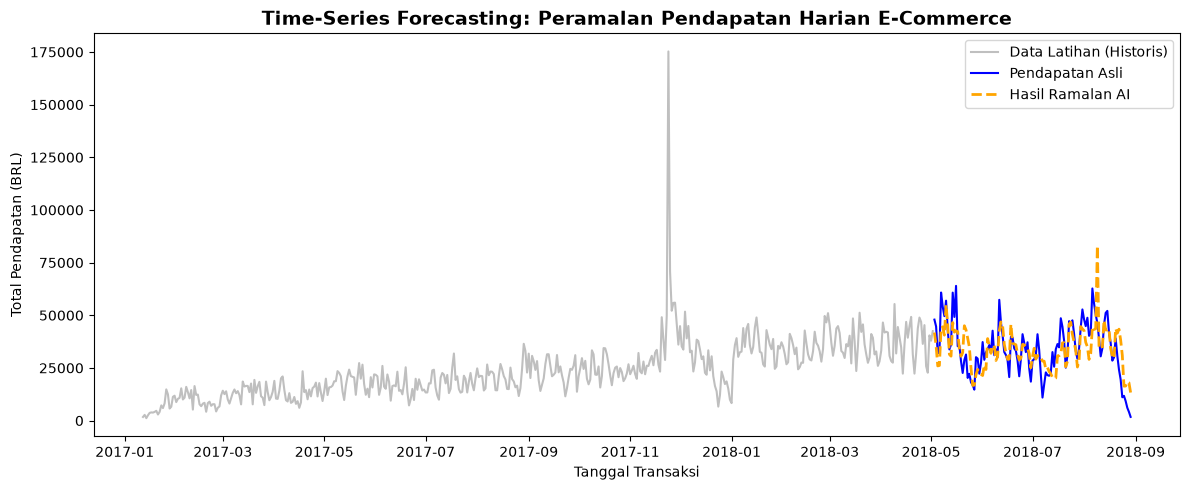

In [1]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

print("1. Mengambil & Mengagregasi Data Pendapatan Harian via DuckDB...")
query = """
SELECT 
    o.order_purchase_timestamp::DATE AS order_date,
    SUM(p.payment_value) AS daily_revenue
FROM read_csv_auto('D:/PROJECT/ecommerce-rfm-churn-pipeline/data/raw/olist_orders_dataset.csv') o
JOIN read_csv_auto('D:/PROJECT/ecommerce-rfm-churn-pipeline/data/raw/olist_order_payments_dataset.csv') p 
    ON o.order_id = p.order_id
WHERE o.order_status = 'delivered'
GROUP BY 1
ORDER BY 1
"""
df_daily = duckdb.query(query).to_df()
df_daily['order_date'] = pd.to_datetime(df_daily['order_date'])

# Membatasi ke rentang waktu transaksi aktif & stabil (2017 hingga pertengahan 2018)
df_daily = df_daily[(df_daily['order_date'] >= '2017-01-01') & (df_daily['order_date'] <= '2018-08-31')].reset_index(drop=True)

print("2. Feature Engineering untuk Time Series (Lag & Rolling Features)...")
df_daily['day_of_week'] = df_daily['order_date'].dt.dayofweek
df_daily['month'] = df_daily['order_date'].dt.month

df_daily['lag_1'] = df_daily['daily_revenue'].shift(1)   # Pendapatan kemarin
df_daily['lag_7'] = df_daily['daily_revenue'].shift(7)   # Pendapatan di hari yang sama minggu lalu
df_daily['rolling_mean_7'] = df_daily['daily_revenue'].shift(1).rolling(7).mean() # Rata-rata moving average 7 hari

df_daily = df_daily.dropna().reset_index(drop=True)

print("3. Time-Series Split (80% Historis Masa Lalu, 20% Masa Depan)...")
# Tidak boleh menggunakan train_test_split biasa yang mengacak urutan waktu
split_idx = int(len(df_daily) * 0.8)
train = df_daily.iloc[:split_idx]
test = df_daily.iloc[split_idx:]

features = ['day_of_week', 'month', 'lag_1', 'lag_7', 'rolling_mean_7']
X_train, y_train = train[features], train['daily_revenue']
X_test, y_test = test[features], test['daily_revenue']

print("4. Melatih Model Forecasting...")
model_forecaster = RandomForestRegressor(n_estimators=100, random_state=42)
model_forecaster.fit(X_train, y_train)

print("5. Evaluasi Hasil Ramalan...")
predictions = model_forecaster.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print(f"\n--- Performa Forecasting Pendapatan ---")
print(f"Error Rata-rata Harian (RMSE): R$ {rmse:.2f}")
print(f"Skor Akurasi (R2 Score): {r2*100:.2f}%")

print("6. Visualisasi Grafik Tren Masa Depan...")
plt.figure(figsize=(12, 5))
plt.plot(train['order_date'], y_train, label='Data Latihan (Historis)', color='gray', alpha=0.5)
plt.plot(test['order_date'], y_test, label='Pendapatan Asli', color='blue', linewidth=1.5)
plt.plot(test['order_date'], predictions, label='Hasil Ramalan AI', color='orange', linestyle='--', linewidth=2)
plt.title('Time-Series Forecasting: Peramalan Pendapatan Harian E-Commerce', fontsize=14, fontweight='bold')
plt.xlabel('Tanggal Transaksi')
plt.ylabel('Total Pendapatan (BRL)')
plt.legend()
plt.tight_layout()
plt.show()